# BetaVAE Hyperparameter Sweep — Analysis
**Run the sweep first:**
```
python scripts/run_betavae_hparam_sweep.py
```
Fixed: `hidden_dim = 16` | Swept: `n_factors`, `lr`, `weight_decay`, `epochs`, `beta`

In [11]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

_cwd = Path(".").resolve()
REPO_ROOT = _cwd if (_cwd / "src").exists() else _cwd.parent
CSV_PATH  = REPO_ROOT / "results" / "beta_hparam" / "betavae_hparam_sweep.csv"

assert CSV_PATH.exists(), f"No sweep file found at {CSV_PATH}\nRun: python scripts/run_betavae_hparam_sweep.py"

df = pd.read_csv(CSV_PATH)
df["gap"] = df["test_mse"] - df["train_mse"]

FACTORS_LIST = sorted(df["n_factors"].unique().tolist())
BETAS        = sorted(df["beta"].unique().tolist())

print(f"Loaded {len(df)} runs from {CSV_PATH}")
print(f"n_factors: {FACTORS_LIST}")
print(f"betas:     {BETAS}")
df.head(3)

Loaded 2688 runs from /Users/michellekadiman/Library/CloudStorage/GoogleDrive-michellekadiman12@gmail.com/My Drive/Github/commodity-research/results/beta_hparam/betavae_hparam_sweep.csv
n_factors: [3, 4, 5, 6, 7, 8, 9]
betas:     [0.3, 0.5, 0.8, 1.0, 2.0, 3.0, 4.0, 5.0]


,n_factors,lr,weight_decay,epochs,beta,train_mse,test_mse,gap
0,8,0.005,0.0000,300,0.3,0.442003,0.506463,0.064460
1,8,0.005,0.0001,300,0.3,0.444109,0.507704,0.063595
2,9,0.005,0.0000,300,0.3,0.443978,0.521150,0.077172


## 1. Top 20 Configs by Train MSE

In [12]:
top20_train = df.sort_values("train_mse").head(20).reset_index(drop=True)
top20_train.index += 1
display(top20_train)

,n_factors,lr,weight_decay,epochs,beta,train_mse,test_mse,gap
1,8,0.005,0.0000,300,0.3,0.442003,0.506463,0.064460
2,9,0.005,0.0000,300,0.3,0.443978,0.521150,0.077172
3,8,0.005,0.0001,300,0.3,0.444109,0.507704,0.063595
4,9,0.005,0.0001,300,0.3,0.446408,0.521655,0.075248
5,8,0.005,0.0000,300,0.5,0.454040,0.522440,0.068400
6,9,0.005,0.0000,300,0.5,0.454983,0.527142,0.072159
7,8,0.005,0.0001,300,0.5,0.456794,0.524127,0.067332
8,9,0.005,0.0001,300,0.5,0.457064,0.529798,0.072734
9,8,0.005,0.0000,200,0.3,0.460106,0.533847,0.073740
10,8,0.005,0.0001,200,0.3,0.462676,0.537319,0.074642


## 2. Top 20 Configs by Test MSE

In [13]:
top20_test = df.sort_values("test_mse").head(20).reset_index(drop=True)
top20_test.index += 1
display(top20_test)

,n_factors,lr,weight_decay,epochs,beta,train_mse,test_mse,gap
1,8,0.005,0.0000,300,0.3,0.442003,0.506463,0.064460
2,8,0.005,0.0001,300,0.3,0.444109,0.507704,0.063595
3,9,0.005,0.0000,300,0.3,0.443978,0.521150,0.077172
4,9,0.005,0.0001,300,0.3,0.446408,0.521655,0.075248
5,8,0.005,0.0000,300,0.5,0.454040,0.522440,0.068400
6,8,0.005,0.0001,300,0.5,0.456794,0.524127,0.067332
7,9,0.005,0.0000,300,0.5,0.454983,0.527142,0.072159
8,9,0.005,0.0001,300,0.5,0.457064,0.529798,0.072734
9,8,0.005,0.0000,200,0.3,0.460106,0.533847,0.073740
10,8,0.005,0.0001,200,0.3,0.462676,0.537319,0.074642


## 3. Best Config Per n_factors

In [14]:
best_per_k = (
    df.sort_values("test_mse")
      .groupby("n_factors", sort=True)
      .first()
      .reset_index()
)
display(best_per_k)

best = df.sort_values("test_mse").iloc[0]
print(f"\nOverall best config:")
print(f"  n_factors    = {int(best.n_factors)}")
print(f"  lr           = {best.lr:g}")
print(f"  weight_decay = {best.weight_decay:g}")
print(f"  epochs       = {int(best.epochs)}")
print(f"  beta         = {best.beta:g}")
print(f"  test MSE     = {best.test_mse:.5f}")
print(f"  train MSE    = {best.train_mse:.5f}")

,n_factors,lr,weight_decay,epochs,beta,train_mse,test_mse,gap
0,3,0.005,0.0,300,0.3,0.636204,0.709971,0.073767
1,4,0.005,0.0,300,0.3,0.589571,0.658280,0.068710
2,5,0.005,0.0,300,0.3,0.549374,0.612981,0.063607
3,6,0.005,0.0,300,0.3,0.513149,0.588918,0.075769
4,7,0.005,0.0,300,0.3,0.476118,0.545331,0.069212
5,8,0.005,0.0,300,0.3,0.442003,0.506463,0.064460
6,9,0.005,0.0,300,0.3,0.443978,0.521150,0.077172



Overall best config:
  n_factors    = 8
  lr           = 0.005
  weight_decay = 0
  epochs       = 300
  beta         = 0.3
  test MSE     = 0.50646
  train MSE    = 0.44200


## 4. Test MSE vs n_factors
Best, median, and worst test MSE across all hyperparameter combinations per factor count.

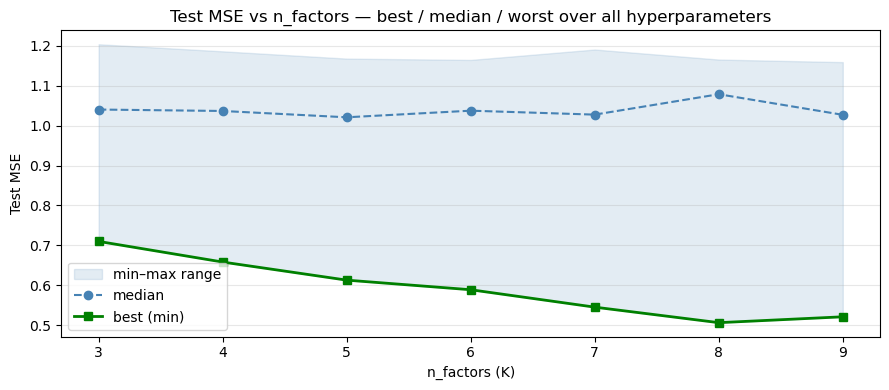

 n_factors      min   median      max
         3 0.709971 1.040201 1.203697
         4 0.658280 1.036597 1.185992
         5 0.612981 1.020773 1.167786
         6 0.588918 1.037336 1.164444
         7 0.545331 1.027472 1.190507
         8 0.506463 1.078537 1.165387
         9 0.521150 1.026967 1.158931


In [15]:
agg = df.groupby("n_factors")["test_mse"].agg(["min", "median", "max"]).reset_index()

fig, ax = plt.subplots(figsize=(9, 4))
ax.fill_between(agg["n_factors"], agg["min"], agg["max"], alpha=0.15, color="steelblue", label="min–max range")
ax.plot(agg["n_factors"], agg["median"], "o--", color="steelblue", lw=1.5, label="median")
ax.plot(agg["n_factors"], agg["min"],    "s-",  color="green",     lw=2,   label="best (min)")
ax.set_xlabel("n_factors (K)")
ax.set_ylabel("Test MSE")
ax.set_title("Test MSE vs n_factors — best / median / worst over all hyperparameters")
ax.set_xticks(FACTORS_LIST)
ax.legend()
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
plt.show()

print(agg.to_string(index=False))

## 5. Heatmap: n_factors × beta
Best test MSE — min over `lr`, `weight_decay`, `epochs`.

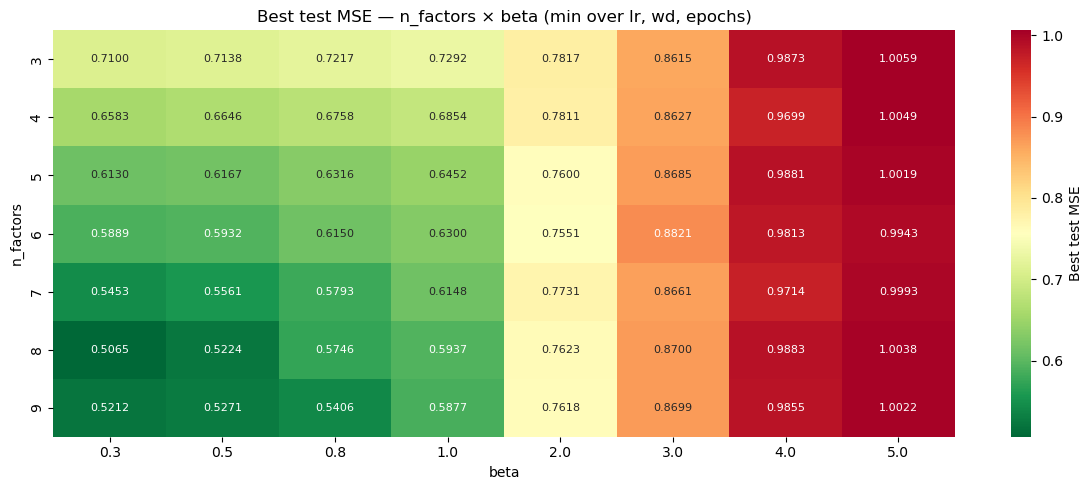

In [16]:
pivot = df.groupby(["n_factors", "beta"])["test_mse"].min().unstack("beta")

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(
    pivot, cmap="RdYlGn_r", annot=True, fmt=".4f",
    annot_kws={"size": 8}, cbar_kws={"label": "Best test MSE"}, ax=ax,
)
ax.set_title("Best test MSE — n_factors × beta (min over lr, wd, epochs)")
ax.set_xlabel("beta")
ax.set_ylabel("n_factors")
fig.tight_layout()
plt.show()

## 6. Heatmap: lr × weight_decay
For the best `n_factors` — min over `epochs` and `beta`.

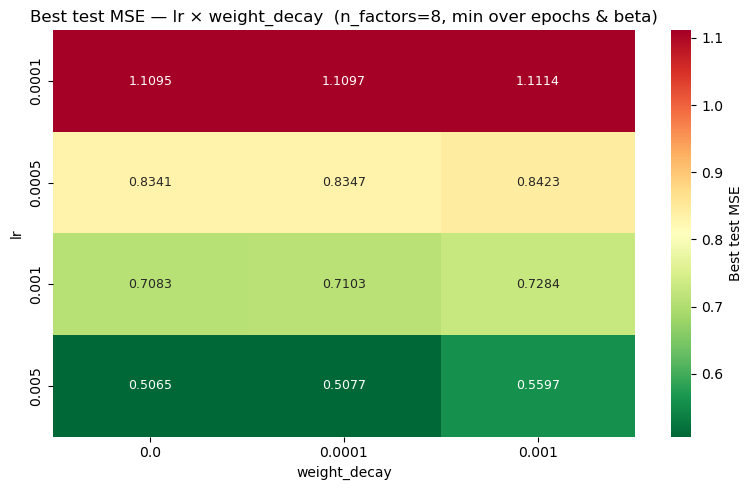

In [17]:
best_k = int(best.n_factors)
sub = df[df["n_factors"] == best_k]
pivot_lr_wd = sub.groupby(["lr", "weight_decay"])["test_mse"].min().unstack("weight_decay")

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(
    pivot_lr_wd, cmap="RdYlGn_r", annot=True, fmt=".4f",
    annot_kws={"size": 9}, cbar_kws={"label": "Best test MSE"}, ax=ax,
)
ax.set_title(f"Best test MSE — lr × weight_decay  (n_factors={best_k}, min over epochs & beta)")
ax.set_xlabel("weight_decay")
ax.set_ylabel("lr")
fig.tight_layout()
plt.show()

## 7. Heatmap: epochs × beta
For the best `n_factors` — min over `lr` and `weight_decay`.

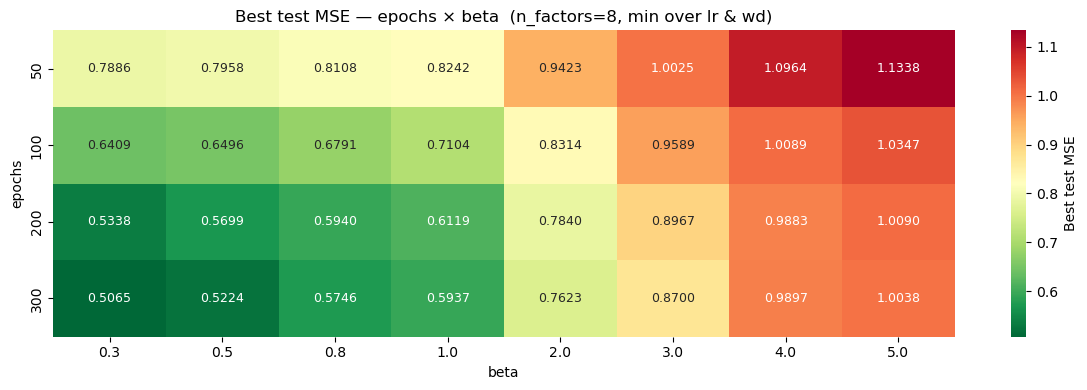

In [18]:
pivot_ep_beta = sub.groupby(["epochs", "beta"])["test_mse"].min().unstack("beta")

fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(
    pivot_ep_beta, cmap="RdYlGn_r", annot=True, fmt=".4f",
    annot_kws={"size": 9}, cbar_kws={"label": "Best test MSE"}, ax=ax,
)
ax.set_title(f"Best test MSE — epochs × beta  (n_factors={best_k}, min over lr & wd)")
ax.set_xlabel("beta")
ax.set_ylabel("epochs")
fig.tight_layout()
plt.show()

## 8. Overfitting View: Train vs Test MSE
Every point sits above the diagonal — that is normal, since the model always fits training data better than unseen test data.
Concern arises only when a point sits **far** above the diagonal relative to others, indicating a large generalisation gap.
Points clustered close to the diagonal are well-generalising configs.

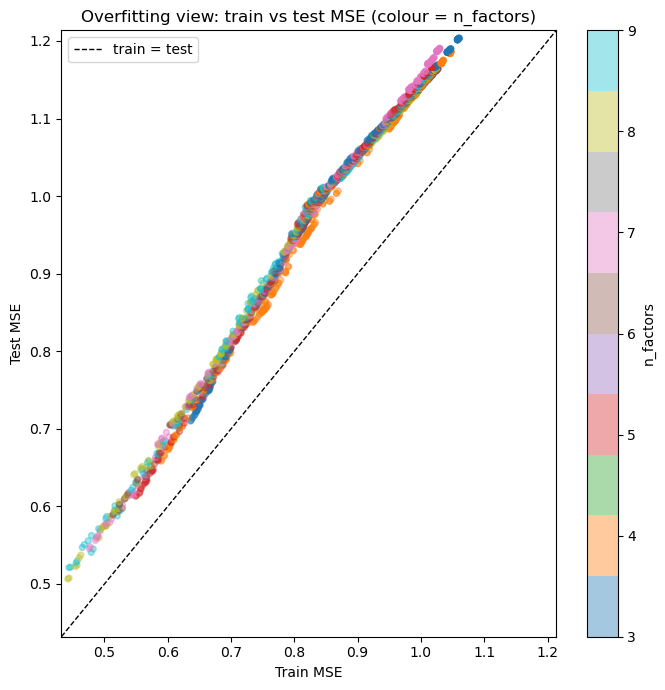

In [19]:
fig, ax = plt.subplots(figsize=(7, 7))
scatter = ax.scatter(
    df["train_mse"], df["test_mse"],
    c=df["n_factors"], cmap="tab10", alpha=0.4, s=18,
)
lims = [min(df["train_mse"].min(), df["test_mse"].min()) - 0.01,
        max(df["train_mse"].max(), df["test_mse"].max()) + 0.01]
ax.plot(lims, lims, "k--", lw=1, label="train = test")
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel("Train MSE")
ax.set_ylabel("Test MSE")
ax.set_title("Overfitting view: train vs test MSE (colour = n_factors)")
plt.colorbar(scatter, ax=ax, label="n_factors")
ax.legend()
fig.tight_layout()
plt.show()

## 9. Generalisation Gap: n_factors × beta

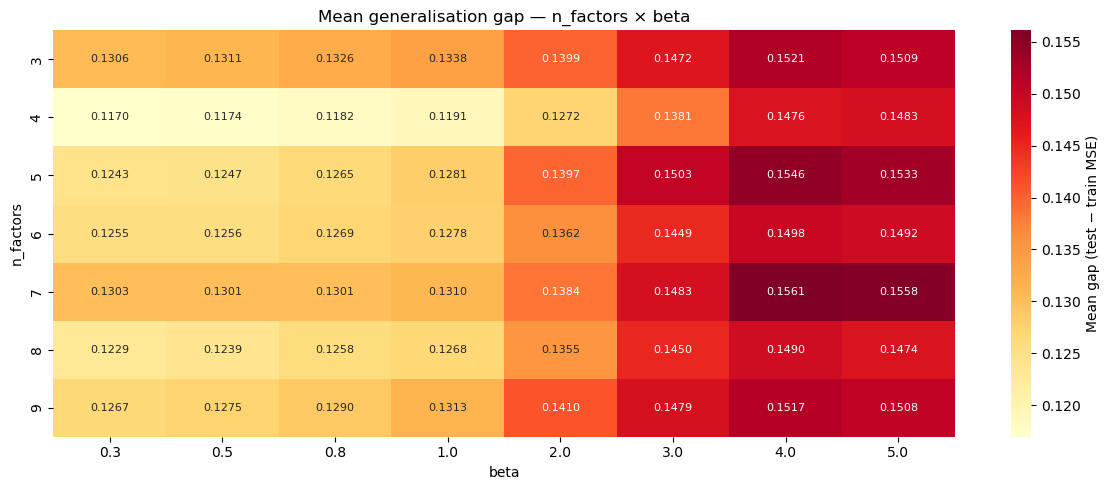

In [20]:
gap_pivot = df.groupby(["n_factors", "beta"])["gap"].mean().unstack("beta")

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(
    gap_pivot, cmap="YlOrRd", annot=True, fmt=".4f",
    annot_kws={"size": 8}, cbar_kws={"label": "Mean gap (test − train MSE)"}, ax=ax,
)
ax.set_title("Mean generalisation gap — n_factors × beta")
ax.set_xlabel("beta")
ax.set_ylabel("n_factors")
fig.tight_layout()
plt.show()